# Assignment 1 — Solutions

Every cell runs from top to bottom in Colab. Comments explain the lines that do
the work; plotting code is commented in blocks.

Where a question asked you to predict first, the answer below gives the right
prediction. Making yours before looking was the exercise.

---

# Part 1 — Two ways a notebook will lie to you

### Q1 — Cells run in the order *you* run them, not the order they appear

Run the next two cells in order. You should get 2,680.19.

In [1]:
deposit = 2000
rate    = 0.05
years   = 6

In [2]:
deposit * (1 + rate) ** years

2680.191281250001

Now, in the cell below, change the rate to **10%** — and do *not* re-run
anything above.

In [3]:
rate = 0.10

In [4]:
# Re-running ONLY the calculation cell. Python uses whatever `rate` holds in
# memory right now — 0.10 — not what is written in the cell above.
deposit * (1 + rate) ** years

3543.1220000000017

Go back and re-run **only** the `deposit * (1 + rate) ** years` cell.

> **(a)** What number do you get now, and why is it not the 5% answer?
>
> **(b)** Now scroll up and re-run the *first* cell, then the calculation cell
> again. What happens, and why?
>
> **(c)** A notebook has an execution *order* and a visual *order*, and they are
> not the same thing. Describe, in one or two sentences, how this could produce a
> number in your final report that you cannot reproduce the next morning.

This is the single most common way a Jupyter result turns out to be wrong, and
AI makes it worse rather than better — pasting a fix halfway up the notebook and
re-running one cell is exactly the move that causes it.

**(a)** **3,543.12.** The calculation uses the value of `rate` currently in
memory, and the last cell to set it said 0.10. Where a cell sits on the page
doesn't matter; when it last ran does.

**(b)** Re-running the first cell sets `rate` back to 0.05, so the calculation
returns **2,680.19** again. Whichever cell ran last wins.

**(c)** If you change a value in a later cell and re-run an earlier calculation,
the number you copy into your report depends on the order you clicked. The next
morning, "Restart and run all" runs the cells top to bottom — a different order —
and gives a different number.

### Q2 — Code that runs, returns a plausible number, and is wrong

You put \$100 into a stock. It returns **+15%** in year one and **−14%** in
year two. The cell below claims to compute what you end up with.

**Do not fix it yet.** First: look at it, and write down what you think it will
print.

In [5]:
r1 = 0.15
r2 = -0.14

100 * 1 + r1 * 1 + r2      # <- what will this print?

100.01

> **(a)** Your prediction, before running:
>
> **(b)** Run it. What did it actually print? Is that number plausible as
> "\$100 after two years"? Would you have caught it if it had appeared in the
> middle of a table?
>
> **(c)** Fix it in the cell below, and state the correct final value.

In [6]:
# * is done before +, so the original line was (100*1) + (r1*1) + r2 = 100.01.
# Returns compound: each year multiplies the balance by (1 + that year's return).
round(100 * (1 + r1) * (1 + r2), 2)     # round to cents

98.9

**(a)** Most people expect something near \$99 or \$101.

**(b)** It prints **100.01**. As "\$100 after two years" it looks perfectly
plausible — which is the problem. In the middle of a table nobody would stop at
it.

**(c)** **\$98.90.** Up 15% and then down 14% loses money, because the 14% loss
is taken on the bigger balance: 100 × 1.15 × 0.86.

---

# Part 2 — Python worth knowing when the AI writes the code

### Q3 — Predict, then run

Below are six statements. `x = 2`, `y = 2`, `z = 4`.

```python
x > z                              # 1
x == y                             # 2
(x < y) and (x > y)                # 3
(x < y) or  (x > y)                # 4
(x <= y) and (x >= y)              # 5
True and ((x < z) or (x < y))      # 6
```

**Write down your six answers first**, as a list like `[True, False, ...]`.
Then run them and compare. Note any you got wrong — `and`/`or` precedence is a
real source of silently wrong filters later in the course.

**Predictions:** `[False, True, False, False, True, True]`

In [7]:
x, y, z = 2, 2, 4
[x > z,                            # 1: 2 > 4                         -> False
 x == y,                           # 2: == compares (a single = stores) -> True
 (x < y) and (x > y),              # 3: False and False               -> False
 (x < y) or  (x > y),              # 4: False or False, since x == y  -> False
 (x <= y) and (x >= y),            # 5: True and True                 -> True
 True and ((x < z) or (x < y))]    # 6: True and (True or False)      -> True

[False, True, False, False, True, True]

### Q4 — Data does not arrive as numbers

You are handed a price as `"$6.50"`. Python sees a string, and `"$6.50" * 2`
gives you `"$6.50$6.50"` rather than 13.

Turn it into the float `6.5`. Then say in one sentence what would happen if a
column of a thousand prices had this problem and you took its mean.

In [8]:
import pandas as pd

price = "$6.50"
clean = price.replace("$", "")     # remove the dollar sign; "6.50" is still text
value = float(clean)               # turn the text into a number
print(value, value * 2)            # 6.5 13.0

# The same fix for a whole column of prices
prices = pd.Series(["$6.50", "$7.00", "$5.25"])
# prices.mean() would raise a TypeError: the column holds text, not numbers
fixed = prices.str.replace("$", "", regex=False).astype(float)   # .str applies it to every row
print(fixed.mean())

6.5 13.0
6.25


**What happens to the mean:** the column is stored as text, so `.mean()` fails
with a `TypeError` — pandas tries to glue the strings together and can't turn
the result into a number. The quieter failure is worse: forcing it with
`pd.to_numeric(..., errors='coerce')` turns every price into `NaN` without
complaint, and whatever you compute next is built on nothing.

### Q5 — Why logs show up everywhere in finance

There is a trick worth knowing: for numbers close to 1, the percent change
$(x-y)/y$ is well approximated by the difference in logs, $\log x - \log y$.

Verify it with the numbers below — compute both and compare. Then try it again
with `x = 2.0, y = 1.0` and report how well the approximation holds.

One sentence: when is it safe to use, and when is it not?

In [9]:
import numpy as np

x, y = 1.05, 1.02
pct = (x - y) / y                   # percent change
lg  = np.log(x) - np.log(y)         # difference in logs
print(f"x=1.05, y=1.02:  percent change {pct:.5f}   log difference {lg:.5f}")

x, y = 2.0, 1.0
pct = (x - y) / y
lg  = np.log(x) - np.log(y)
print(f"x=2.0,  y=1.0 :  percent change {pct:.5f}   log difference {lg:.5f}")

x=1.05, y=1.02:  percent change 0.02941   log difference 0.02899
x=2.0,  y=1.0 :  percent change 1.00000   log difference 0.69315


**When it holds, and when it breaks:** for small changes the two agree —
2.94% against 2.90%. For large ones they don't: doubling is a 100% change but a
log change of only 0.69. Safe for monthly returns of a few percent; not for a
stock that doubles or halves.

---

# Part 3 — Real data, which does not want to help you

Everything from here uses one Excel file: 49 US industry portfolios from Ken
French, monthly, going back to 1926, plus a sheet with the market return and the
risk-free rate.

```
https://raw.githubusercontent.com/amoreira2/UG54/refs/heads/main/assets/data/Assignment1.xlsx
```

**Download it and open it in Excel before you write any code.** Ten seconds of
looking will save you an hour. This is a habit, not a suggestion.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [10, 4]

URL = ("https://raw.githubusercontent.com/amoreira2/UG54/"
       "refs/heads/main/assets/data/Assignment1.xlsx")
pd.ExcelFile(URL).sheet_names

['Market_proxy', '49_Industry_Portfolios']

### Q6 — Load it, and count the columns

Read the `49_Industry_Portfolios` sheet. The real column names are **not** in
the first row — there are several lines of description above them, so you will
need `skiprows`.

Then answer this before going further: **how many columns did you get?**

> **(a)** How many columns are there, and how many industries were you promised?
>
> **(b)** Print the column names. Some of them end in `.1` and `.2`. What has
> happened, and what would you have computed if you had just averaged everything?
>
> **(c)** Keep only the block you actually want — the value-weighted returns —
> and say how you know it is the right one.

In [11]:
# The industry names are on the 7th row of the sheet: skip the six lines above
raw = pd.read_excel(URL, sheet_name='49_Industry_Portfolios', skiprows=6)
print(raw.shape)
print(list(raw.columns))

(1069, 152)
['Unnamed: 0', 'Agric', 'Food', 'Soda', 'Beer', 'Smoke', 'Toys', 'Fun', 'Books', 'Hshld', 'Clths', 'Hlth', 'MedEq', 'Drugs', 'Chems', 'Rubbr', 'Txtls', 'BldMt', 'Cnstr', 'Steel', 'FabPr', 'Mach', 'ElcEq', 'Autos', 'Aero', 'Ships', 'Guns', 'Gold', 'Mines', 'Coal', 'Oil', 'Util', 'Telcm', 'PerSv', 'BusSv', 'Hardw', 'Softw', 'Chips', 'LabEq', 'Paper', 'Boxes', 'Trans', 'Whlsl', 'Rtail', 'Meals', 'Banks', 'Insur', 'RlEst', 'Fin', 'Other', 'Unnamed: 50', 'Unnamed: 51', 'Agric.1', 'Food.1', 'Soda.1', 'Beer.1', 'Smoke.1', 'Toys.1', 'Fun.1', 'Books.1', 'Hshld.1', 'Clths.1', 'Hlth.1', 'MedEq.1', 'Drugs.1', 'Chems.1', 'Rubbr.1', 'Txtls.1', 'BldMt.1', 'Cnstr.1', 'Steel.1', 'FabPr.1', 'Mach.1', 'ElcEq.1', 'Autos.1', 'Aero.1', 'Ships.1', 'Guns.1', 'Gold.1', 'Mines.1', 'Coal.1', 'Oil.1', 'Util.1', 'Telcm.1', 'PerSv.1', 'BusSv.1', 'Hardw.1', 'Softw.1', 'Chips.1', 'LabEq.1', 'Paper.1', 'Boxes.1', 'Trans.1', 'Whlsl.1', 'Rtail.1', 'Meals.1', 'Banks.1', 'Insur.1', 'RlEst.1', 'Fin.1', 'Other.1

In [12]:
# The row just above the names labels each block of columns
labels = pd.read_excel(URL, sheet_name='49_Industry_Portfolios', header=None, skiprows=5, nrows=1)
labels.iloc[0].dropna()          # the column position where each label sits

1                     Average
2                       Value
3                    Weighted
4                     Returns
5                          --
6                     Monthly
52                    Average
53                       Firm
54                       Size
55                    Monthly
103    Average BE/ME Annually
Name: 0, dtype: object

**(a)** **152 columns**, for 49 industries: one date column, then three blocks
of 49, with two empty columns between blocks.

**(b)** The same 49 names appear three times. A DataFrame can't have two
columns with the same name, so pandas renames the repeats `Agric.1`, `Agric.2`,
and so on. The row above the names (printed below) says what the blocks are:
value-weighted returns, average firm size, and average book-to-market. Averaging
everything would mix monthly returns with firm sizes in millions of dollars and
book-to-market ratios.

**(c)** The first block, columns 1 to 49. Its label reads *Average Value
Weighted Returns — Monthly*, and its numbers look like monthly returns in
percent.

In [13]:
ind = raw.iloc[:, :50].copy()                          # position 0 = date, 1 to 49 = value-weighted returns
ind = ind.rename(columns={ind.columns[0]: 'date'})     # the date column arrived with no name ('Unnamed: 0')
print(ind.shape)

(1069, 50)


### Q7 — Missing values that are not missing

The header text says: *"All missing values are indicated by -99.99 or -999."*

Find them and replace them with proper `NaN`. Then report what fraction of the
table was missing.

> **⚠️** If you skip this, `-99.99` is a perfectly valid number and every mean,
> standard deviation and correlation you compute will quietly include it as a
> **−99.99% monthly return**. Nothing will error.

In [14]:
returns = ind.drop(columns='date')                          # everything except the date
n_bad = returns.isin([-99.99, -999]).sum().sum()            # True counts as 1: total sentinel cells

ind = ind.replace([-99.99, -999], np.nan)                   # both codes become proper missing values
share = ind.drop(columns='date').isna().mean().mean()       # mean of True/False = share missing

print(f"{n_bad:,} cells were -99.99 or -999")
print(f"{share:.1%} of the return table is missing")

2,877 cells were -99.99 or -999
5.5% of the return table is missing


### Q8 — Dates and units

Two more things stand between you and usable data.

**Dates.** The first column is an integer like `192607`. Convert it to a proper
month-end date and make it the index. Month-*end* matters: these are monthly
returns, and later in the course you will merge them against other series that
are stamped at month end. A one-day mismatch silently drops every row.

**Units.** Print the mean of one industry. Is it a monthly return of 0.9%, or
90%? Convert so that a 1% return is stored as `0.01`.

In [15]:
# 192607 -> text '192607' -> 1 July 1926 -> moved to the last day of that month
ind['date'] = pd.to_datetime(ind['date'].astype(str), format='%Y%m') + pd.offsets.MonthEnd(0)
ind = ind.set_index('date')      # the dates become the row labels

# Before converting: Agric's mean is about 0.96 — that is 0.96% a month, not 96%
ind = ind / 100                  # percent -> decimal, so a 1% return is 0.01

print(ind.index[:3])
print(f"mean monthly return, Agric: {ind['Agric'].mean():.5f}")

DatetimeIndex(['1926-07-31', '1926-08-31', '1926-09-30'], dtype='datetime64[ns]', name='date', freq=None)
mean monthly return, Agric: 0.00964


### Q9 — Excess returns

Load the `Market_proxy` sheet the same way — it has `Mkt-RF` and `RF`. Watch the
units here too.

Then build excess returns two ways:

1. For **one** industry, `Agric`, subtract `RF` month by month. Print its mean.
2. For **all 49 at once**, in a single line, producing a DataFrame called `inde`.

> **🤖 Worth asking the AI:** *"subtract a Series from every column of a
> DataFrame, aligning on the index"* — and then check that the row count did not
> change. Getting the axis wrong here produces a table full of NaN, or worse, a
> table that looks fine and is transposed.

In [16]:
mkt = pd.read_excel(URL, sheet_name='Market_proxy', skiprows=5)      # this sheet's header is on the 6th row
mkt = mkt.rename(columns={mkt.columns[0]: 'date'})
mkt['date'] = pd.to_datetime(mkt['date'].astype(str), format='%Y%m') + pd.offsets.MonthEnd(0)
mkt = mkt.set_index('date') / 100                                      # percent here too

print(f"industries: {ind.index.min():%Y-%m} to {ind.index.max():%Y-%m}, {len(ind)} months")
print(f"market    : {mkt.index.min():%Y-%m} to {mkt.index.max():%Y-%m}, {len(mkt)} months\n")

# 1. One industry. Subtracting two Series lines them up by date first.
agric_ex = (ind['Agric'] - mkt['RF']).dropna()
print(f"Agric mean excess return: {agric_ex.mean():.5f} per month")

# 2. All 49 at once.
rf   = mkt['RF'].reindex(ind.index)      # RF on exactly the industry months
inde = ind.sub(rf, axis=0)               # axis=0: match rf to the ROWS (dates), not the columns
print(f"inde: {inde.shape}   same rows as ind: {len(inde) == len(ind)}\n")

# The two traps from the hint
print("without the reindex :", ind.sub(mkt['RF'], axis=0).shape, "<- four extra months with no industry data")
print("with the wrong axis :", ind.sub(rf).shape, "<- dates matched against industry names: all NaN")

industries: 1926-07 to 2015-07, 1069 months
market    : 1926-07 to 2015-11, 1073 months

Agric mean excess return: 0.00682 per month
inde: (1069, 49)   same rows as ind: True

without the reindex : (1073, 49) <- four extra months with no industry data
with the wrong axis : (1069, 1118) <- dates matched against industry names: all NaN


### Q10 — Dropping rows has a price

Not every industry exists in 1926. To get a rectangular table where every
industry covers the same months, drop the incomplete rows.

Report: how many months you had before, how many after, and **what date the
sample now starts**.

> **(a)** How many months did that cost you?
>
> **(b)** You have just thrown away 40 years of data to keep 49 columns. Name
> one thing you might have done instead, and say what it would have cost.

In [17]:
full = inde.dropna()          # keep only the months in which all 49 industries have a return

print(f"before: {len(inde)} months, from {inde.index.min():%Y-%m}")
print(f"after : {len(full)} months, from {full.index.min():%Y-%m}")
print(f"cost  : {len(inde) - len(full)} months\n")

# Which industries force the late start? The first month each one has data:
first = ind.apply(lambda col: col.first_valid_index())
print(first[first > ind.index.min()].sort_values().dt.strftime('%Y-%m').to_string())

before: 1069 months, from 1926-07
after : 553 months, from 1969-07
cost  : 516 months

PerSv    1927-07
Paper    1929-07
Rubbr    1930-07
Soda     1963-07
FabPr    1963-07
Guns     1963-07
Gold     1963-07
Softw    1965-07
Hlth     1969-07


**(a)** **516 months** — 43 years. The sample now starts in **July 1969**, the
first month Health has data.

**(b)** Drop columns instead of rows. Nine industries start after July 1926;
without them you keep all 1,069 months, with 40 industries — but you lose
Software, Health, Gold and Guns. A middle road: drop only Health and Software and
keep 625 months from July 1963. Or keep the gaps and compute each statistic on
whatever months exist — you keep everything, but different industries' numbers
then come from different periods and can't be compared directly.

### Q11 — The two objects everything else is built from

Compute and display:

1. `ERe` — the vector of **annualized** mean excess returns, one per industry
2. `CovRe` — the **annualized** covariance matrix of excess returns

> **If you have not met a covariance matrix.** For 49 industries it is a 49×49
> table. The diagonal entry $(i,i)$ is industry $i$'s **variance** — its
> volatility squared. The off-diagonal entry $(i,j)$ is the **covariance**
> between $i$ and $j$: positive when the two tend to move in the same direction,
> negative when one tends to rise as the other falls, near zero when neither
> tells you much about the other.
>
> A **correlation** is that same covariance divided by the two volatilities,
> which rescales it to sit between −1 and +1. Same information, easier to read —
> which is why the question below asks you for correlations rather than raw
> covariances.
>
> `df.cov()` builds the whole table in one call. Nothing in the next few weeks
> needs it. It comes back in Capital Allocation in October, where it is the
> object that decides how much of each thing to hold.

Report the highest and lowest average-return industries. Then print the
correlation between three pairs of your choosing — pick one pair you expect to
move together and one you expect not to, and say whether the data agreed.

Remember: means annualize by ×12, variances by ×12, volatilities by ×√12.

In [18]:
ERe   = full.mean() * 12      # annualized mean excess return: one number per industry
CovRe = full.cov() * 12       # annualized 49x49 covariance matrix; variances on the diagonal

print("highest:", (ERe.nlargest(3) * 100).round(1).to_dict(), "% a year")
print("lowest :", (ERe.nsmallest(3) * 100).round(1).to_dict(), "% a year\n")

corr = full.corr()            # the same information as CovRe, rescaled to lie between -1 and +1
for a, b in [('Banks', 'Insur'), ('Softw', 'Chips'), ('Gold', 'Banks')]:
    print(f"corr({a}, {b}) = {corr.loc[a, b]:.2f}")

CovRe.iloc[:4, :4].round(4)   # one corner of the matrix

highest: {'Smoke': 12.9, 'Fun': 10.9, 'Guns': 10.6} % a year
lowest : {'Other': 0.9, 'RlEst': 1.8, 'PerSv': 2.7} % a year

corr(Banks, Insur) = 0.81
corr(Softw, Chips) = 0.69
corr(Gold, Banks) = 0.12


,Agric,Food,Soda,Beer
Agric,0.0507,0.0167,0.0172,0.0184
Food,0.0167,0.0248,0.0206,0.0200
Soda,0.0172,0.0206,0.0533,0.0258
Beer,0.0184,0.0200,0.0258,0.0341


**Highest and lowest:** over July 1969 to July 2015, Tobacco (`Smoke`, 12.9% a
year), Entertainment (`Fun`, 10.9%) and Defense (`Guns`, 10.6%) earned the most;
`Other` (0.9%), Real Estate (1.8%) and Personal Services (2.7%) the least.

**Pairs:**
- **Banks and Insurance**, expected to move together — both are financial firms
  exposed to the same rates and credit. Correlation **0.81**: they do.
- **Software and Chips**, expected together — the same tech cycle. **0.69**.
- **Gold and Banks**, expected to have little to do with each other. **0.12**:
  nearly unrelated.

### Q12 — Look at it

Pick **two** industries that you think behaved very differently in some
identifiable episode — a crisis, a boom, a technological shift.

1. Plot their monthly excess returns over that period.
2. Plot the **cumulative** return of \$1 invested in each over that period.
3. In three or four sentences, say what happened, using the actual magnitudes
   from your plot. What would \$1 have become in each?

> **📌** Cumulative returns compound: `(1 + r).cumprod()`, not `r.cumsum()`.
> Adding returns is Lecture 1's pitfall 4 and the error grows with horizon.

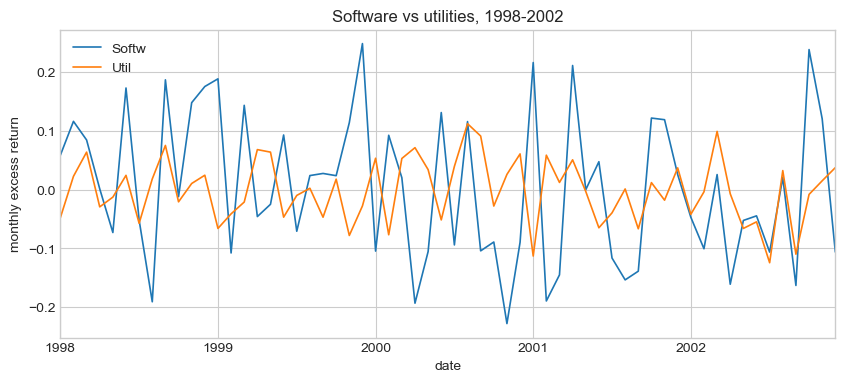

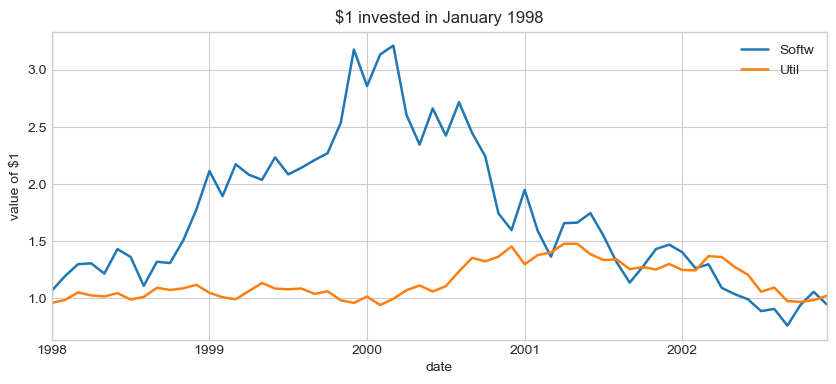

Softw: peak $3.21 in Mar 2000, low $0.76 in Sep 2002, $0.94 at the end
Util: best $1.47, $1.02 at the end


In [19]:
a, b = 'Softw', 'Util'
period = slice('1998-01', '2002-12')     # the dot-com boom and bust

# 1 — monthly excess returns (plotting)
fig, ax = plt.subplots()
inde.loc[period, [a, b]].plot(ax=ax, linewidth=1.2)
ax.set_ylabel('monthly excess return'); ax.set_title('Software vs utilities, 1998-2002')
plt.show()

# 2 — growth of $1: compound the total returns month by month
growth = (1 + ind.loc[period, [a, b]]).cumprod()

# plotting
fig, ax = plt.subplots()
growth.plot(ax=ax, linewidth=1.8)
ax.set_ylabel('value of $1'); ax.set_title('$1 invested in January 1998')
plt.show()

after_peak = growth[a].loc[growth[a].idxmax():]
print(f"{a}: peak ${growth[a].max():.2f} in {growth[a].idxmax():%b %Y}, "
      f"low ${after_peak.min():.2f} in {after_peak.idxmin():%b %Y}, ${growth[a].iloc[-1]:.2f} at the end")
print(f"{b}: best ${growth[b].max():.2f}, ${growth[b].iloc[-1]:.2f} at the end")

**What happened:** software rode the internet boom — \$1 invested in January 1998
was worth **\$3.21** by March 2000, with single months of +25%. Then the bust
took it down to **\$0.76** by September 2002, and it ended 2002 at **\$0.94**:
below where it started, after tripling along the way. Utilities barely took part
in either: their best was **\$1.47**, and they ended at **\$1.02**. Same five
years, and two industries that could hardly have had a more different ride.